D:\setup\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2489
Model:               ARIMA(14, 1, 14)   Log Likelihood                7304.515
Date:                Fri, 09 May 2025   AIC                         -14551.031
Time:                        23:28:31   BIC                         -14382.273
Sample:                             0   HQIC                        -14489.749
                               - 2489                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2249      0.881     -0.255      0.799      -1.953       1.503
ar.L2         -0.1096      0.992     -0.110      0.912      -2.054       1.835
ar.L3         -0.1097      0.886     -0.124      0.9

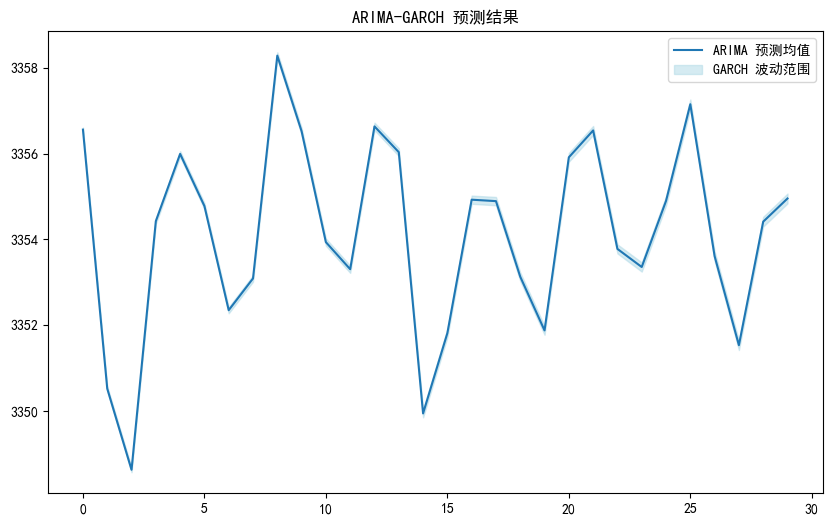

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from itertools import product

# 1. 加载数据
data = pd.read_csv("../data/shangzheng_test.csv")
ts_data = data['deal_data'].values

# 对原始数据取对数
ts_data_log = np.log(ts_data)

arima_model = ARIMA(ts_data_log, order=(14,1,14))
arima_result = arima_model.fit()
print(arima_result.summary())

# 3. 提取 ARIMA 模型的残差
residuals = arima_result.resid

# 4. 自动选择 GARCH 参数并拟合 GARCH 模型
p_range = range(1, 4)
q_range = range(1, 4)
min_aic = np.inf
best_p, best_q = None, None

for p, q in product(p_range, q_range):
    try:
        garch_model = arch_model(residuals, vol="Garch", p=p, q=q)
        garch_result = garch_model.fit(disp="off")
        if garch_result.aic < min_aic:
            min_aic = garch_result.aic
            best_p, best_q = p, q
    except:
        continue

print(f"最优 GARCH 参数 (p, q): ({best_p}, {best_q})")

best_garch_model = arch_model(residuals, vol="Garch", p=best_p, q=best_q)
best_garch_result = best_garch_model.fit()
print(best_garch_result.summary())

# 5. 预测
# ARIMA 预测均值（对数尺度）
arima_forecast_log = arima_result.forecast(steps=30)

# 将对数尺度的预测值转换回原始尺度
arima_forecast = np.exp(arima_forecast_log)

# GARCH 预测条件方差
garch_forecast = best_garch_result.forecast(horizon=30)
garch_variance = garch_forecast.variance.iloc[-1].values

# 6. 将结果保存到 DataFrame
results_df = pd.DataFrame({
    "ARIMA 预测均值": arima_forecast,
    "GARCH 预测条件方差": garch_variance,
    "最终预测下限": arima_forecast - np.sqrt(garch_variance),
    "最终预测上限": arima_forecast + np.sqrt(garch_variance)
})

# 7. 保存到 Excel 文件
results_df.to_excel("../results/shangzheng_forecast_new.xlsx", index=False)

print("预测结果已保存到 ../results/shangzheng_forecast_new.xlsx")

# 8. 可视化结果
plt.figure(figsize=(10, 6))
plt.plot(arima_forecast, label="ARIMA 预测均值")
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.fill_between(
    range(len(arima_forecast)),
    arima_forecast - np.sqrt(garch_variance),
    arima_forecast + np.sqrt(garch_variance),
    color="lightblue",
    alpha=0.5,
    label="GARCH 波动范围"
)
plt.title("ARIMA-GARCH 预测结果")
plt.legend()
plt.show()